# Task 3: Customer Churn Analysis using Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to analyze customer churn behavior using the Telco Customer Churn dataset.

Customer churn refers to customers who stop using a company's services. Understanding churn patterns helps businesses improve customer retention strategies and reduce revenue loss.

This analysis focuses on:

- Understanding dataset structure
- Data cleaning and preprocessing
- Identifying important customer characteristics
- Visualizing churn patterns
- Extracting business insights

# Import Required Libraries

In this step, we import the necessary Python libraries used for:

- Data manipulation (Pandas, NumPy)
- Data visualization (Matplotlib, Seaborn)
- Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Load Dataset

The Telco Customer Churn dataset contains information about customers, their subscription details, demographics, payment methods, and churn status.

We load the dataset and preview the first few records.

# Dataset Information

Understanding dataset dimensions and column data types is important before performing any analysis.

This step provides:

- Number of rows and columns
- Data types
- Missing value information

In [2]:
print("Shape:", df.shape)

df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

# Statistical Summary

The statistical summary helps us understand:

- Distribution of numerical variables
- Minimum and maximum values
- Average values
- Variability in the dataset

In [3]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# Missing Value Analysis

Missing values can affect model performance and analytical accuracy.

We check each column to identify any missing records.

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Checking TotalCharges Data Type

The TotalCharges column is expected to be numeric.

We verify its data type because datasets often contain blank spaces or formatting issues that prevent numerical analysis.

In [5]:
print(df["TotalCharges"].dtype)

df["TotalCharges"].head()

object


0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

# Data Cleaning and Preprocessing

Before performing analysis, it is important to clean the dataset and ensure all columns have appropriate data types.

In this step we:

- Fix data type issues
- Handle missing values
- Prepare the dataset for visualization and analysis

(df["TotalCharges"] == " ").sum()

# Fixing TotalCharges Column

The TotalCharges column should be numerical.

Some records contain blank spaces which prevent the column from being treated as numeric.

We convert the column into a numeric datatype and replace invalid values with NaN.

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

df["TotalCharges"].isnull().sum()

float64


np.int64(11)

# Handling Missing Values

The missing values generated during conversion are replaced using the median value of the column.

Median is preferred because it is less sensitive to outliers.

In [10]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

df.isnull().sum().sum()

C:\Users\anuja\AppData\Local\Temp\ipykernel_5736\3164773190.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


np.int64(0)

## Observation

After handling missing values, the dataset contains no null values.

The TotalCharges column has been successfully converted into a numeric datatype and all missing values have been replaced using the median value.

The dataset is now ready for further analysis and visualization.

# Feature Engineering

Feature engineering helps create new variables that improve analysis and uncover hidden patterns.

We create:

1. Tenure Group
2. Average Monthly Spend

In [11]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

df["TenureGroup"].head()

0     0-12 Months
1    25-48 Months
2     0-12 Months
3    25-48 Months
4     0-12 Months
Name: TenureGroup, dtype: category
Categories (4, object): ['0-12 Months' < '13-24 Months' < '25-48 Months' < '49-72 Months']

# Creating Average Monthly Spend

Average Monthly Spend is calculated as:

Average Monthly Spend = Total Charges / Tenure

This feature provides insight into customer spending behavior.

In [12]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

df[
    ["TotalCharges",
     "tenure",
     "AvgMonthlySpend"]
].head()

,TotalCharges,tenure,AvgMonthlySpend
0,29.85,1,14.925000
1,1889.50,34,53.985714
2,108.15,2,36.050000
3,1840.75,45,40.016304
4,151.65,2,50.550000


# Churn Distribution Analysis

Understanding churn distribution is important because it shows how many customers have left versus how many customers have remained.

This helps identify class imbalance and provides an overview of customer retention.

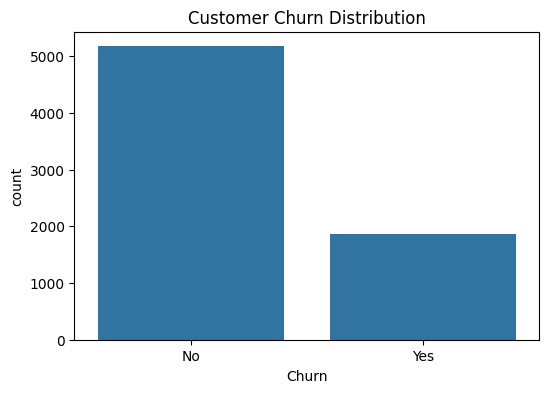

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.savefig(
    "../outputs/churn_outputs/churn_distribution.png"
)

plt.show()

## Observation

The chart shows the distribution of customers who churned and those who stayed.

A higher number of retained customers indicates overall customer loyalty, while the churned customers represent potential revenue loss and require further investigation.

# Contract Type vs Churn Analysis

Contract type plays a significant role in customer retention.

In this section, we analyze how different contract plans affect customer churn rates.

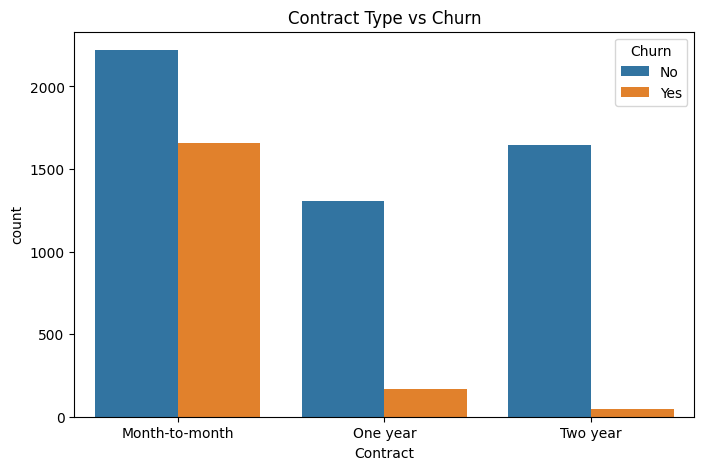

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")

plt.savefig(
    "../outputs/churn_outputs/contract_vs_churn.png"
)

plt.show()

## Observation

Customers with month-to-month contracts show a significantly higher churn rate.

Customers with one-year and two-year contracts are more likely to remain with the company.

Long-term contracts improve customer retention and reduce churn.

# Payment Method vs Churn Analysis

Payment methods can influence customer behavior and subscription continuity.

This analysis helps identify whether certain payment methods are associated with higher churn.

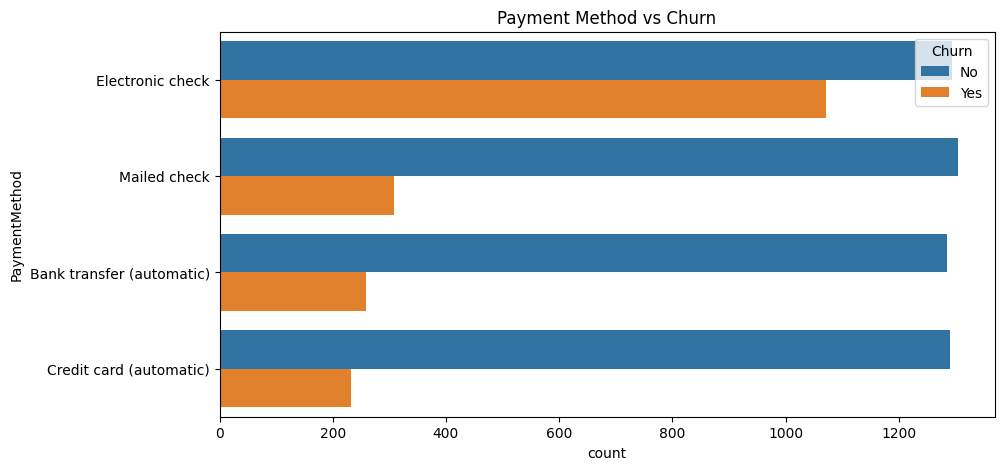

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Payment Method vs Churn")

plt.savefig(
    "../outputs/churn_outputs/payment_method_vs_churn.png"
)

plt.show()

## Observation

Electronic check users exhibit a higher churn rate compared to other payment methods.

Customers using automatic payment options tend to remain longer with the company.

Encouraging automated payment methods may help reduce churn.

# Tenure Group vs Churn Analysis

Customer tenure represents how long customers have stayed with the company.

This analysis helps understand whether newer customers are more likely to churn than long-term customers.

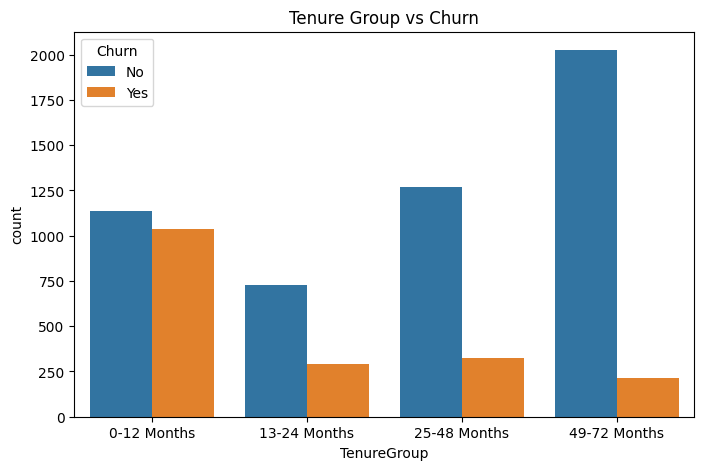

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TenureGroup",
    hue="Churn",
    data=df
)

plt.title("Tenure Group vs Churn")

plt.savefig(
    "../outputs/churn_outputs/tenure_vs_churn.png"
)

plt.show()

## Observation

Customers with shorter tenure show a higher tendency to churn.

Long-term customers are generally more loyal and less likely to leave.

The company should focus on customer engagement during the early months of service.

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

A heatmap provides a visual representation of these relationships.

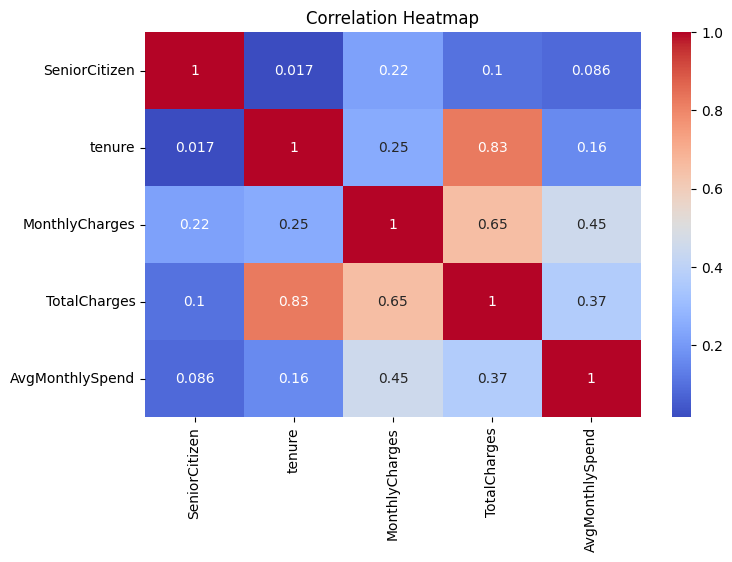

In [18]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/churn_outputs/correlation_heatmap.png"
)

plt.show()

## Observation

The heatmap shows the correlation among numerical variables.

Tenure and TotalCharges generally have a positive relationship because customers who stay longer accumulate more charges.

No extremely strong correlations are observed, indicating that multiple factors contribute to customer churn.

# Monthly Charges Analysis

Monthly charges represent the recurring revenue generated from customers.

This analysis compares monthly charges between churned and retained customers.

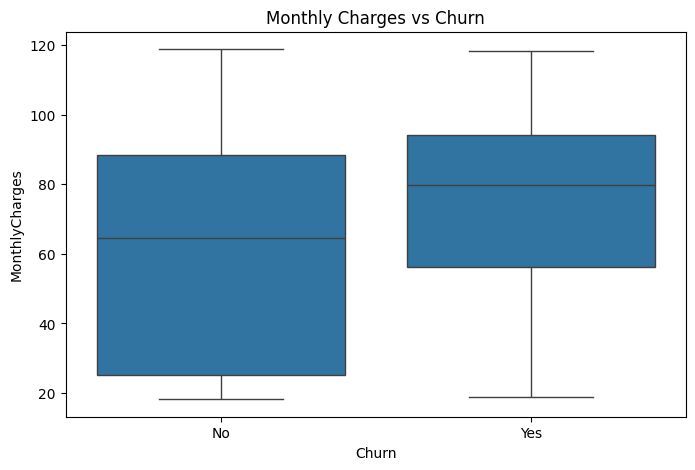

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig(
    "../outputs/churn_outputs/monthly_charges_vs_churn.png"
)

plt.show()

## Observation

Customers who churn tend to have slightly higher monthly charges.

This suggests that pricing may influence customer decisions.

The company can investigate pricing strategies and offer suitable plans to improve retention.

# Senior Citizen Analysis

Senior citizens may exhibit different customer behavior compared to younger customers.

This analysis evaluates churn patterns among senior citizens.

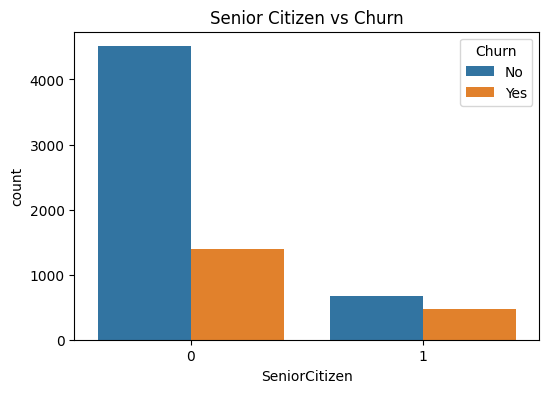

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.savefig(
    "../outputs/churn_outputs/seniorcitizen_vs_churn.png"
)

plt.show()

## Observation

Senior citizens show a different churn pattern compared to non-senior customers.

Understanding these differences can help design targeted retention programs and customer support services.

# Key Business Insights

1. Month-to-month contracts have the highest churn rate.

2. Customers with shorter tenure are more likely to leave.

3. Electronic check users exhibit higher churn behavior.

4. Customers paying higher monthly charges show a greater tendency to churn.

5. Long-term contract customers demonstrate stronger loyalty and retention.

# Conclusion

This Customer Churn Analysis project explored customer behavior using Exploratory Data Analysis (EDA).

Several factors were identified as contributors to customer churn, including contract type, tenure, payment method, and monthly charges.

The findings suggest that encouraging long-term contracts, improving customer engagement during the early stages of subscription, and promoting automatic payment methods may help reduce churn.

This analysis provides valuable business insights that can support customer retention strategies and improve overall customer satisfaction.

# End of Project

Project Completed Successfully

Dataset:
WA_Fn-UseC_-Telco-Customer-Churn Dataset

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

Author:
Anushree S Jambagi

Internship:
Data Science Internship – Month 2

Task:
Customer Churn Analysis using Exploratory Data Analysis (EDA)